In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv("ushape.csv", header=None)
df.columns = ['X', 'Y', 'class']

In [12]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


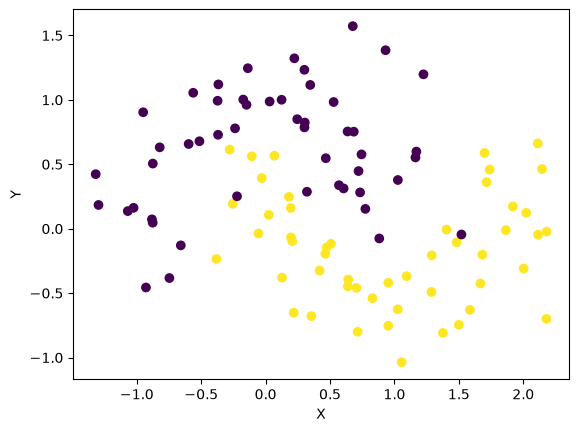

In [14]:
plt.scatter(
    df['X'],
    df['Y'],
    c=df['class']
)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [16]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.get_weights()

[array([[-0.1980633 , -1.6027917 , -1.7375655 ,  0.1797584 , -1.8147721 ,
          0.9243821 , -1.1208678 , -0.9144944 ,  1.1744944 ,  0.12563616],
        [-2.0534158 ,  1.2996396 ,  0.53431344,  1.3458962 , -0.51885545,
         -0.00529499, -0.603955  , -0.86047685, -2.1112156 , -0.68223363]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.11306577,  0.31272095, -0.16896081, -0.4816813 ,  0.07554261,
          0.48005   ,  0.7919132 , -0.2735957 , -0.16914406,  0.01452978],
        [ 0.3754056 ,  0.24885967,  0.62649196,  0.48886633, -0.6671775 ,
          0.31871006, -0.7889265 ,  0.4806687 ,  0.51728827, -0.37138852],
        [ 0.5527409 ,  0.04626401, -0.97024614, -0.28713056,  0.275248  ,
          0.31522816,  0.46064004, -0.5982056 , -0.03722631,  0.38423142],
        [-0.3832457 ,  0.61761916,  0.7831984 ,  0.32677266, -0.5994479 ,
         -0.7006185 , -0.5416334 ,  0.7132845 ,  0.19194001,  0.18181616],
        [ 0.03319

In [19]:
initial_weights = model.get_weights()

In [20]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [21]:
model.set_weights(initial_weights)

In [22]:
model.get_weights()

[array([[ 1.3406676 ,  0.633111  ,  0.3277574 ,  0.1860781 ,  0.03716424,
          0.6344541 ,  0.19410197, -0.04442082,  0.5241262 ,  0.47384048],
        [-0.15713674,  0.8537285 ,  0.46873662,  0.10346281,  0.3061477 ,
         -0.12111824, -0.42559984, -0.20205219,  0.06409229,  0.38270628]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.20093794, -0.675727  , -0.6466246 , -0.18550424, -0.28741905,
         -0.36142683,  0.5142435 , -0.74836195,  0.47069862,  0.05304413],
        [-0.8125249 ,  0.47263557, -0.16437602, -0.0339862 , -0.09801774,
         -0.45327643,  0.61616737,  0.23775329, -0.02837538,  0.2762448 ],
        [-0.37994754, -0.01156474,  0.10746795, -0.02758203,  0.01019636,
         -0.06757741,  0.38296902, -0.18427391, -0.27657366, -0.2648871 ],
        [-0.20663443, -0.3713833 , -0.32733357,  0.09059092,  0.07166487,
         -0.06940389,  0.14550474, -0.07711436, -0.08810262, -0.08104255],
        [ 0.24059

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 533ms/step - accuracy: 0.6875 - loss: 0.6774 - val_accuracy: 0.6000 - val_loss: 0.6774
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7000 - loss: 0.6721 - val_accuracy: 0.6500 - val_loss: 0.6714
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7125 - loss: 0.6667 - val_accuracy: 0.7000 - val_loss: 0.6647
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7000 - loss: 0.6604 - val_accuracy: 0.7000 - val_loss: 0.6575
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7125 - loss: 0.6543 - val_accuracy: 0.7000 - val_loss: 0.6496
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7500 - loss: 0.6485 - val_accuracy: 0.7000 - val_loss: 0.6415
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7500 - loss: 0.6416 - val_accuracy: 0.7000 - val_loss: 0.6333
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7625 - loss: 0.6355 - val_accuracy: 0.7000 - v

In [25]:
model.get_weights()

[array([[ 1.4251435 ,  0.5664388 ,  0.25217783,  0.11621562,  0.12450576,
          0.77036226,  0.33673355,  0.07170428,  0.43974409,  0.5758269 ],
        [-0.39097372,  0.9844343 ,  0.5595647 ,  0.20699063,  0.50101656,
         -0.22084841, -0.6264876 , -0.3733838 ,  0.11161143,  0.20766531]],
       dtype=float32),
 array([-0.01389401, -0.02132053,  0.00900559,  0.02148531,  0.14921784,
         0.12450226,  0.15789971,  0.15130821,  0.23314895,  0.06936944],
       dtype=float32),
 array([[ 3.1027827e-01, -6.4931780e-01, -6.4662462e-01, -2.3317972e-01,
         -2.8741905e-01, -3.6142683e-01,  4.9855489e-01, -6.2965775e-01,
          5.5935520e-01, -4.2908464e-04],
        [-7.4129313e-01,  5.2291727e-01, -2.1514449e-01, -3.7354991e-02,
          6.6093571e-02, -4.5327643e-01,  6.7507631e-01,  4.1327646e-01,
         -2.5987644e-02,  2.4633448e-01],
        [-3.0850419e-01,  3.7037633e-02,  5.4442305e-02, -1.4612336e-02,
          1.6013893e-01, -6.7577414e-02,  4.5624426e-01, -7

In [30]:
# from mlxtend.plotting import plot_decision_regions
# plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

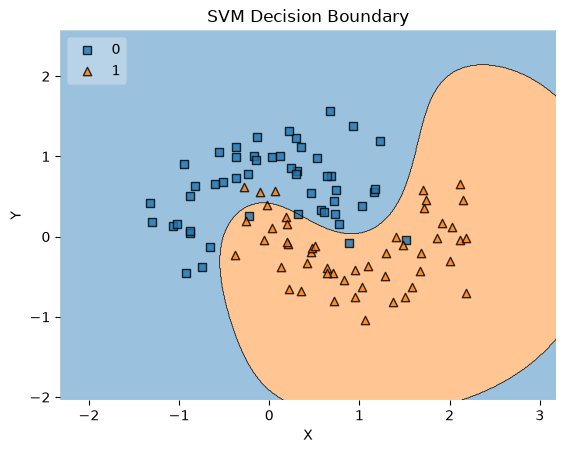

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

# Load CSV
df = pd.read_csv("ushape.csv", header=None)

# Add column names
df.columns = ['X', 'Y', 'class']

# Convert to numeric NumPy arrays
X = df[['X', 'Y']].astype(float).values
y = df['class'].astype(int).values

# Train SVM
model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

model.fit(X, y)

# Plot decision boundary
plot_decision_regions(
    X,
    y,
    clf=model,
    legend=2
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("SVM Decision Boundary")
plt.show()

In [27]:
(np.random.randn(10,10)*0.01).min()

np.float64(-0.023225508776172587)

In [28]:
(np.random.randn(10,10)*0.01).max()

np.float64(0.021380328745675015)